In [1]:
import sys
import os
from pathlib import Path

import torch

sys.path.append(os.path.abspath("../src"))

from models import DenseNet121

from data import (
    prepare_full_dataframe, 
    prepare_data, 
    create_binary_target,
    sample_image_path,
    get_transforms
)

from train_eval import (
    setup_training,
    train_model,
    evaluate,
    predict_single_image
)

from utils import (
    get_device,
    plot_training_history,
    plot_confusion_matrix_figure,
    get_model_path
)
import config

/Users/tommy_tran/cxr-ai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_path = "/Volumes/Secretary/Datasets/NIH_Chest_X-Rays"
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")
df = prepare_full_dataframe(metadata_file, dataset_path)

print("Total images:", len(df))
print("Unique patients:", df["Patient ID"].nunique())
df["Finding Labels"].value_counts().head()

Dataset location: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays
Total images: 112120
Unique patients: 30805


Finding Labels
No Finding      60361
Infiltration     9547
Atelectasis      4215
Effusion         3955
Nodule           2705
Name: count, dtype: int64

In [3]:
print(df["split"].value_counts())

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [4]:
train_loader, val_loader, test_loader = prepare_data(df)

device = get_device()

model = DenseNet121(num_classes=2, in_channels=1).to(device)

criterion, optimizer = setup_training(model)

Using MPS (GPU)


In [5]:
history = train_model(model, train_loader, val_loader, criterion, optimizer, device, "densenet121_binary_target", 3)
# Batch size = 16, Image size = 128

Val Epoch 1: 100%|██████████| 1055/1055 [05:20<00:00,  3.29it/s, avg_acc=0.6637, avg_loss=0.6235]


Epoch 1/10 | ETA (Remaining): 04:43:17 | Total ETA: 05:14:45
  Train Loss: 0.6414 | Train Acc: 0.6378
  Val Loss: 0.6235 | Val Acc: 0.6637
  Val Precision: 0.6266
  Val Recall: 0.6498 | Val F1: 0.6380
------------------------------------------------------------
Saved best model to /Users/tommy_tran/cxr-ai/saved_models/densenet121_binary_target.pt
------------------------------------------------------------


Val Epoch 2: 100%|██████████| 1055/1055 [04:27<00:00,  3.94it/s, avg_acc=0.6835, avg_loss=0.6091]


Epoch 2/10 | ETA (Remaining): 04:00:28 | Total ETA: 05:14:45
  Train Loss: 0.6182 | Train Acc: 0.6677
  Val Loss: 0.6091 | Val Acc: 0.6835
  Val Precision: 0.6621
  Val Recall: 0.6251 | Val F1: 0.6431
------------------------------------------------------------
Saved best model to /Users/tommy_tran/cxr-ai/saved_models/densenet121_binary_target.pt
------------------------------------------------------------


Val Epoch 3: 100%|██████████| 1055/1055 [04:28<00:00,  3.92it/s, avg_acc=0.6856, avg_loss=0.6055]


...

Epoch 7/10 | ETA (Remaining): 01:25:13 | Total ETA: 05:14:45
  Train Loss: 0.5845 | Train Acc: 0.7013
  Val Loss: 0.5966 | Val Acc: 0.6946
  Val Precision: 0.6865
  Val Recall: 0.6078 | Val F1: 0.6448
------------------------------------------------------------
No improvement. Patience: 1/3
------------------------------------------------------------


Val Epoch 8: 100%|██████████| 1055/1055 [04:27<00:00,  3.94it/s, avg_acc=0.6964, avg_loss=0.5911]


Epoch 8/10 | ETA (Remaining): 00:57:04 | Total ETA: 05:14:45
  Train Loss: 0.5788 | Train Acc: 0.7054
  Val Loss: 0.5911 | Val Acc: 0.6964
  Val Precision: 0.6915
  Val Recall: 0.6037 | Val F1: 0.6446
------------------------------------------------------------
No improvement. Patience: 2/3
------------------------------------------------------------


Val Epoch 9: 100%|██████████| 1055/1055 [04:20<00:00,  4.05it/s, avg_acc=0.6951, avg_loss=0.6024]


Epoch 9/10 | ETA (Remaining): 00:28:32 | Total ETA: 05:14:45
  Train Loss: 0.5729 | Train Acc: 0.7115
  Val Loss: 0.6024 | Val Acc: 0.6951
  Val Precision: 0.6849
  Val Recall: 0.6138 | Val F1: 0.6474
------------------------------------------------------------
No improvement. Patience: 3/3
------------------------------------------------------------
Early stopping at epoch 9 (patience 3 exceeded)


(<Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>)

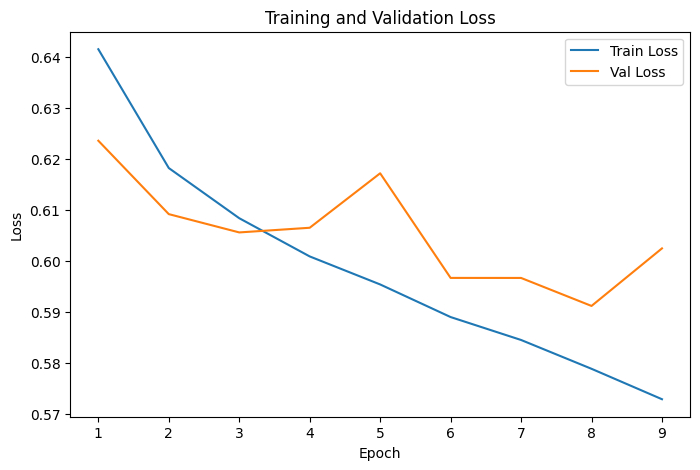

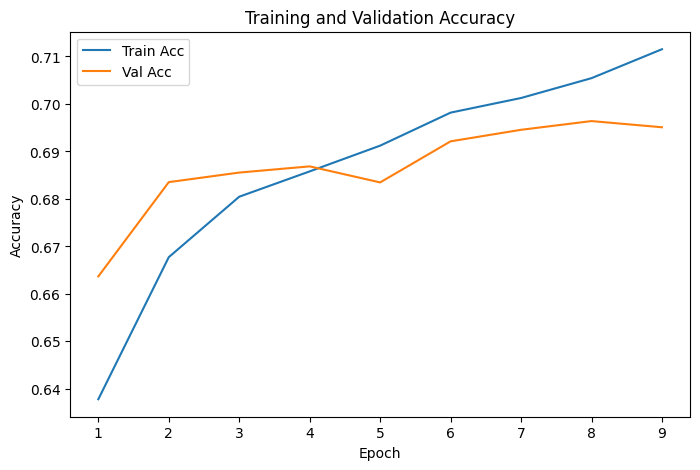

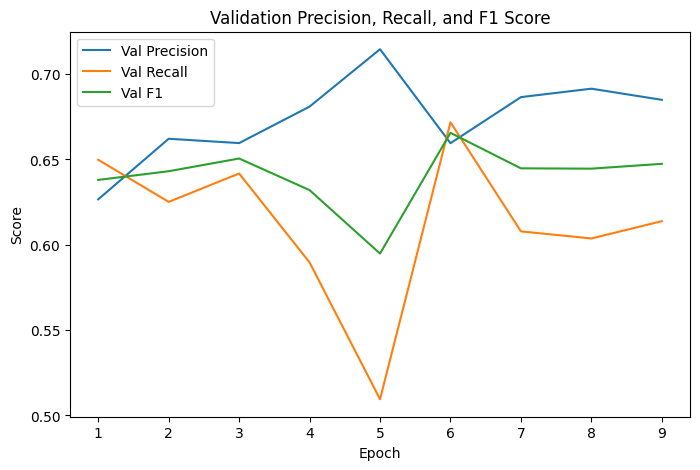

In [6]:
plot_training_history(history)

In [8]:
save_path = get_model_path("densenet121_binary_target")
print(save_path)
config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_model = DenseNet121(num_classes=2, in_channels=1).to(device)
best_model.load_state_dict(torch.load(save_path))

test_loss, test_acc, test_precision, test_recall, test_f1, test_labels, test_preds = evaluate(
    best_model, test_loader, criterion, device
)

print("Test Results")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1 Score: {test_f1:.4f}")

/Users/tommy_tran/cxr-ai/saved_models/densenet121_binary_target.pt


Val: 100%|██████████| 1020/1020 [04:18<00:00,  3.94it/s, avg_acc=0.6941, avg_loss=0.5933]


Test Results
  Loss: 0.5933
  Accuracy: 0.6941
  Precision: 0.6650
  Recall: 0.6810
  F1 Score: 0.6729


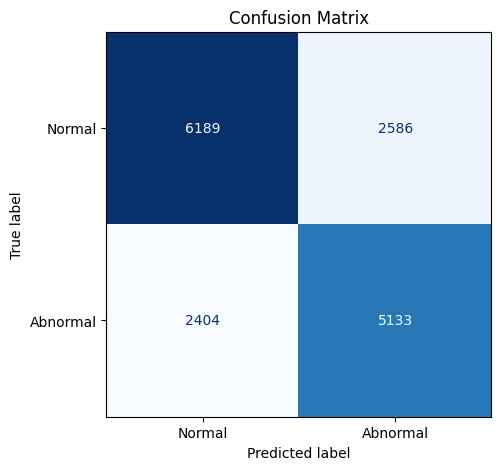

In [9]:
plot_confusion_matrix_figure(test_labels, test_preds, ["Normal", "Abnormal"])

In [31]:
import random

image_path = sample_image_path(df, split="test", seed=random.randint(0, 2**32 - 1))
_, eval_transforms = get_transforms()

result = predict_single_image(image_path, best_model, device, eval_transforms, df=df)

print("Image path:", image_path)
print("Predicted class:", result["predicted_class"])
print("True label:", result["true_label"])
print("Probabilities:", result["probabilities"])

Image path: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays/images_003/images/00005950_005.png
Predicted class: abnormal
True label: abnormal
Probabilities: {'normal': 0.479894757270813, 'abnormal': 0.520105242729187}
